<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-II/blob/main/Clase%209/An%C3%A1lisis_Multivariado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Analisis Multivariado
### Coderhouse - Data Science
Profe Jorge Ruiz

tomado del ejemplo http://saber.ucv.ve/bitstream/10872/18490/1/Otros%20Coeficientes%20Correlaci%C3%B3n_FHE_UCV.pdf

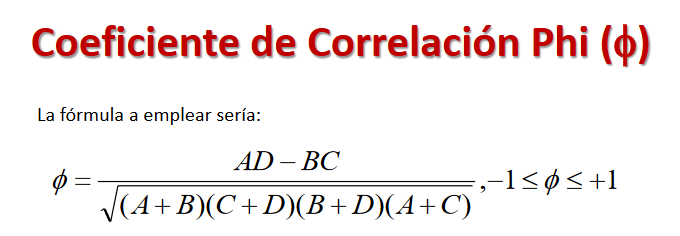

Donde:

a es la frecuencia de la combinación de valores "0 0"

b es la frecuencia de la combinación de valores "0 1"

c es la frecuencia de la combinación de valores "1 0"

d es la frecuencia de la combinación de valores "1 1"

In [ ]:
import pandas as pd

# pandas.crosstab function returns the contingency table

df = pd.DataFrame({
    "Xi": [0, 1, 1, 0, 0, 1, 1, 1, 0, 1],
    "Yi": [0, 0, 1, 0, 1, 1, 1, 1, 0, 1]
})

frecuencia= pd.crosstab(df["Xi"], df["Yi"])


frecuencia

Aplicando la fórmula a la tabla de frecuencia:

a = 3
b = 1
c = 1
d = 5

φ = (3 * 5 - 1 * 1) / √((3 + 1) * (1 + 5) *  (1 + 5)*(3 + 1) )


φ = (15 - 1) / √(4 * 6 * 6 * 4)


φ = 14 / √(576)


φ = 14 / 24


φ ≈ 0.583

##Prueba de los rangos con signo de Wilcoxon


La prueba no paramétrica más utilizada para verificar si dos medias son iguales es la prueba de Wilcoxon. Esta prueba no asume que los datos provienen de una distribución normal.

La prueba de Wilcoxon se basa en la comparación de los rangos de los datos de los dos grupos. Los rangos se asignan a los datos de menor a mayor, sin tener en cuenta los valores reales de los datos.

Hipótesis nula: No hay diferencia (en términos de tendencia central) entre los dos grupos de la población.

Hipótesis alternativa: Existe una diferencia (con respecto a la tendencia central) entre los dos grupos de la población.

In [ ]:
#Importamos las librerias

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:


#Ejemplo médico:
# Debes comprobar si el tiempo de reacción es mejor en horas de la mañana o por la noche.

# Datos del grupo 1 (mañana)
g_mañana = [34, 36,41,39,44,37,39,39,45]

# Datos del grupo 1 (nocturno)
g_noche = [45,33,35,43,42,42,43,43,42]

# prueba de Wilcoxon
w = stats.wilcoxon(g_mañana, g_noche)

print(w)
# al ser 0.35 mayor a 0.05 no rechazamos H. Nula. Por lo tanto, podemos afirmar que no hay una diferencia entre ambos grupos en sus medias de tiempo de reacción.

print("media del grupo de la mañana :",np.array(g_mañana).mean())
print("media del grupo de la noche :",np.array(g_noche).mean())


# adaptado del ejemplo https://datatab.es/tutorial/wilcoxon-test

# Ejemplo 1

In [ ]:
df= sns.load_dataset("iris")
df

In [ ]:
df.shape

In [ ]:
f, axs = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw=dict(width_ratios=[5, 5]))
sns.scatterplot(data=df, x="sepal_length", y="petal_width", hue="species", ax=axs[0])
sns.histplot(data=df, x="species", hue="species", shrink=.8, alpha=.4, legend=False, ax=axs[1])
f.tight_layout()

In [ ]:
sns.scatterplot(data=df, x="sepal_length", y="petal_length", hue="species").set(title='sepal_length vs petal_length')


In [ ]:
#Pairplot
sns.pairplot(df,hue = 'species' , height= 3 , palette = 'Set2')


#hue: Una variable categórica que se utiliza para colorear los puntos de la dispersión.
#size: El tamaño de los puntos
#palette: Una paleta de colores que se utiliza para colorear los puntos, recuerden que pueden usar la que prefieran


# revisar https://seaborn.pydata.org/generated/seaborn.pairplot.html

# Ejemplo 2

In [ ]:
#Importamos las librerias
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('darkgrid')

In [ ]:
url='https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
df =pd.read_csv(url,sep=',')
df.columns= ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df.head()

Pregnancies: The number of pregnancies that the patient has had.

Glucose: The patient's blood glucose level in mg/dL.

BloodPressure: The patient's blood pressure in mmHg.

SkinThickness: The patient's skin thickness in mm.

Insulin: The patient's 2-hour post-prandial serum insulin in μU/mL.

BMI: The patient's body mass index (BMI).

DiabetesPedigreeFunction: A measure of the patient's genetic predisposition to diabetes.

Age: The patient's age in years.

Outcome: The patient's diabetes status, where 1 indicates that the patient has diabetes and 0 indicates that the patient does not have diabetes.

In [ ]:
#Reemplazar el Outcome de 1 a 'Diab' y 0 a 'Non-Diab'
df.Outcome = df.Outcome.replace({0:'Non-Diab',1:'Diab'})
df.head()

In [ ]:
#Renombrar la columna DiabetesPedigreeFunction a DPF
df.DiabetesPedigreeFunction = df.rename({'DiabetesPedigreeFunction':'DPF'},inplace = True,axis =1)
df.head()

In [ ]:
#Verificamos los tipos de datos
df.dtypes

In [ ]:
#Convertir a la variable: DPF en Integer y verificar su correcta conversion
df["DPF"] = pd.to_numeric(df["DPF"])

In [ ]:
#Validacion cambio de dato
df.dtypes

In [ ]:
#Shape
df.shape

In [ ]:
#Info
df.info()

In [ ]:
#Estadisticos básicos
df.describe().T

In [ ]:
#Crear el Pairplot con el atributo hue = 'Outcome'. Las leyendas deberán decir: 'Non Diabetic','Diabetic'

sns.pairplot(df,hue = 'Outcome',palette = 'plasma')
plt.legend(['Non Diabetic','Diabetic'])
plt.show()

In [ ]:
#Correlaciones
df= df.drop("Outcome", axis=1)
plt.figure(dpi = 120,figsize= (5,4))
mask = np.triu(np.ones_like(df.corr(),dtype = bool))
sns.heatmap(df.corr(),mask = mask, fmt = ".2f",annot=True,lw=1,cmap = 'plasma')
plt.yticks(rotation = 0)
plt.xticks(rotation = 90)
plt.title('Correlation Heatmap')
plt.show()

# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

**Insight**: La glucosa muestra una asociación lineal débil positiva con las otras variables del conjunto de datos. Eso significa que al aumentar el nivel de glucosa en los pacientes, también aumentarán las otras variables.

**Insight**: BloodPressure muestra una asociación lineal débil positiva con las otras variables del conjunto de datos dado. Eso significa que al aumentar el nivel de BP en los pacientes, también aumentarán el resto de las variables.

**Insight**: SkinThickness muestra una asociación lineal débil positiva con el resto de las variables, excepto con la edad. Eso significa que al aumentar el SkinThickness en los pacientes, las otras variables también aumentarán. SkinThickness con la edad muestran una correlación negativa débil es decir, al aumentar SkinThickness, la edad disminuirá.

In [ ]:
from sklearn.linear_model import LinearRegression

data_ = df
"""
x1,x2,x3,X4

x1= x2,x3,X4
x2= x1,x3,X4
x3= x1,x2,X4
x4= x1,x2,X3
"""
# Manual VIF Calculation
vif_manual = {}

for feature in data_ .columns:
    # Define the target variable (current feature) and predictors (all other features)
    y = data_[feature]
    X = data_.drop(columns=[feature])

    # Fit the linear regression model
    model = LinearRegression().fit(X, y)

    # Calculate R-squared
    r_squared = model.score(X, y)

    # Calculate VIF
    vif = 1 / (1 - r_squared)
    vif_manual[feature] = vif

# Convert the dictionary to a DataFrame for better display
vif_manual_df = pd.DataFrame(list(vif_manual.items()), columns=['Feature', 'VIF'])
print(vif_manual_df)

# adaptado desde https://www.datacamp.com/es/tutorial/variance-inflation-factor

In [ ]:
# https://es.wikipedia.org/wiki/Factor_de_inflaci%C3%B3n_de_la_varianza
# https://statologos.com/como-calcular-vif-en-python/
# https://www.osakidetza.euskadi.eus/hipertension-arterial-en-la-diabetes/webosk00-oeshta/es/#:~:text=No%20obstante%2C%20las%20consecuencias%20de,las%20personas%20con%20hipertensi%C3%B3n%20arterial.
# https://www.solucionesparaladiabetes.com/magazine-diabetes/relacion-entre-el-consumo-de-azucar-y-la-hipertension/

VIF igual a 1: Un VIF de 1 indica que no hay colinealidad entre la variable predictora y las demás variables. Esto significa que la variable no está correlacionada con ninguna otra variable en el modelo.

VIF entre 1 y 5: Un VIF en este rango generalmente se considera aceptable y sugiere una colinealidad leve o moderada entre la variable predictora y otras variables. No es motivo de preocupación grave, pero se debe tener en cuenta al interpretar los coeficientes de regresión.

VIF mayor a 5: Un VIF mayor a 5 indica una colinealidad sustancial entre la variable predictora y al menos una de las otras variables. Esto puede sugerir que la variable está  muy correlacionada con otras variables y puede dificultar la interpretación de los coeficientes de regresión.

VIF muy alto: En casos donde el VIF es extremadamente alto (por ejemplo, superior a 10 o 20), se considera que la colinealidad es muy fuerte. Esto indica que la variable está altamente correlacionada con otras variables y puede afectar significativamente las estimaciones de los coeficientes de regresión.